<a href="https://colab.research.google.com/github/AJx005/MyProjects/blob/main/RetailX_Final_Project_AOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step 1: Import required libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# Load the RetailX dataset
retail_df = pd.read_excel('RetailX.xlsx')

# Display the first few rows and summary info to understand the dataset
retail_df.head()

,Cust_No,avg_order_size,avg_order_freq,crossbuy,multichannel,per_sale,tenure,return_rate,married,own_home,household_size,loyalty_card,income,age,avg_mktg_cnt,zip_code,segment
0,1,23.400000,2.222222,3,2,0.000000,3,0.117521,1,1,1,1,35,47,56.000000,21230,6
1,2,34.260377,6.625000,7,2,0.111111,35,0.281868,1,1,3,1,140,70,14.914286,22301,2
2,3,43.575641,4.875000,5,2,0.074074,12,0.274177,1,0,4,0,35,21,20.083333,19002,1
3,4,26.316667,0.900000,4,2,0.250000,9,0.143551,0,0,1,1,35,62,8.222222,22304,4
4,5,8.269231,1.083333,3,1,0.500000,40,0.000000,0,0,2,0,140,21,1.350000,20124,2


In [ ]:
#Step 2: Choosing demographic variables to segment our customers
features = ['age', 'income', 'avg_order_size', 'avg_order_freq', 'crossbuy', 'multichannel', 'per_sale', 'tenure', 'return_rate', 'married', 'own_home', 'household_size', 'loyalty_card', 'income', 'avg_mktg_cnt']
X = retail_df[features]

In [ ]:
#Step 3: Data Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

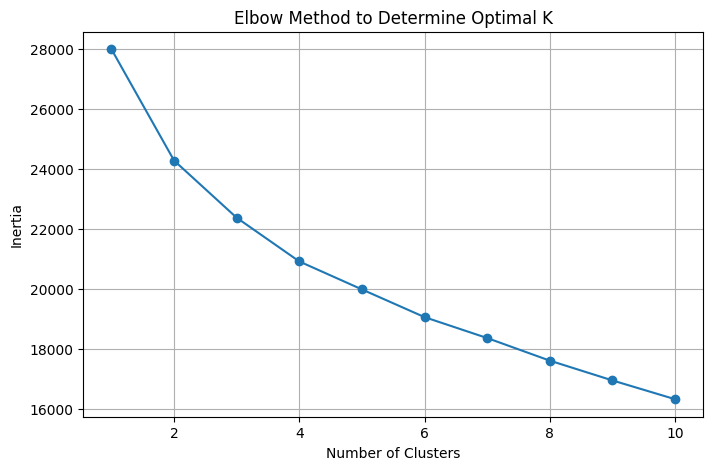

In [ ]:
#Drop non-feature columns and scale
features = retail_df.drop(columns=["Cust_No", "zip_code", "segment"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#Elbow Method for K
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()
plt.show()

In [ ]:
#Step 5: Apply K-means to Cluster Customers into 3 segments (0,1,2)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
retail_df['cluster'] = kmeans.fit_predict(scaled_features)
print(retail_df.head(5))

   Cust_No  avg_order_size  avg_order_freq  crossbuy  multichannel  per_sale  \
0        1       23.400000        2.222222         3             2  0.000000   
1        2       34.260377        6.625000         7             2  0.111111   
2        3       43.575641        4.875000         5             2  0.074074   
3        4       26.316667        0.900000         4             2  0.250000   
4        5        8.269231        1.083333         3             1  0.500000   

   tenure  return_rate  married  own_home  household_size  loyalty_card  \
0       3     0.117521        1         1               1             1   
1      35     0.281868        1         1               3             1   
2      12     0.274177        1         0               4             0   
3       9     0.143551        0         0               1             1   
4      40     0.000000        0         0               2             0   

   income  age  avg_mktg_cnt  zip_code  segment  cluster  
0      35

In [ ]:
#Segment Profiling. Step 1: Segment Profile Table
retail_df.groupby('cluster').agg({
    'age': 'mean',
    'income': 'mean',
    'avg_order_size': 'mean',
    'avg_order_freq': 'mean',
    'crossbuy': 'mean',
    'multichannel': 'mean',
    'per_sale': 'mean',
    'tenure': 'mean',
    'return_rate': 'mean',
    'married': 'mean',
    'own_home': 'mean',
    'household_size': 'mean',
    'loyalty_card': 'mean',
    'avg_mktg_cnt': 'mean',
    'Cust_No': 'count'  #To check how many people in each segment
}).rename(columns={'Cust_No': 'count'})

,age,income,avg_order_size,avg_order_freq,crossbuy,multichannel,per_sale,tenure,return_rate,married,own_home,household_size,loyalty_card,avg_mktg_cnt,count
cluster,,,,,,,,,,,,,,,
0,42.978469,69.665072,33.269285,3.924960,4.485646,2.203349,0.090887,12.495215,0.175994,0.423445,0.593301,3.035885,0.631579,28.343357,418
1,44.089372,96.461353,30.896162,1.492292,3.190821,1.741546,0.353140,32.847826,0.201735,0.867150,0.345411,2.210145,0.565217,5.016166,414
2,42.505993,70.650685,37.712478,0.731474,1.729452,1.260274,0.019205,8.065925,0.168087,0.334760,0.637842,3.042808,0.632705,10.230004,1168


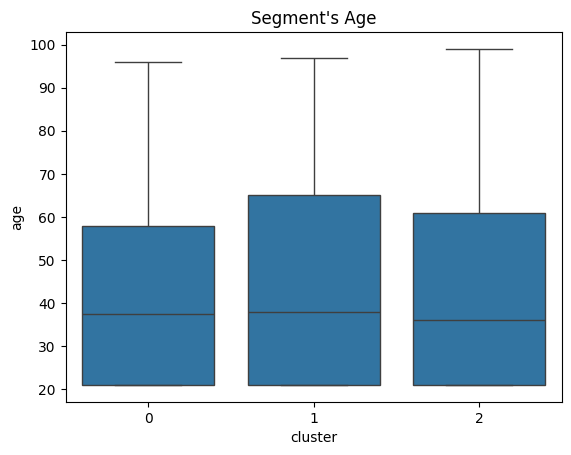

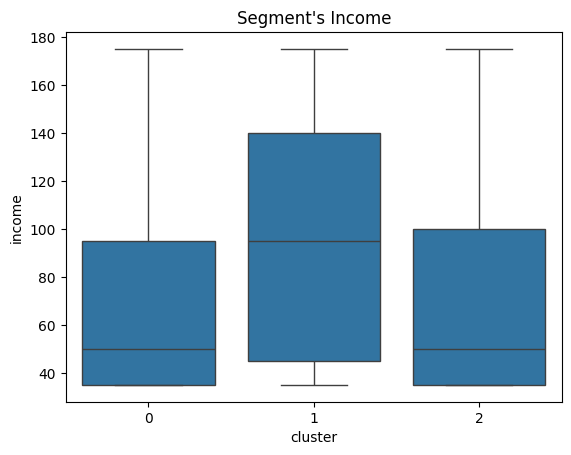

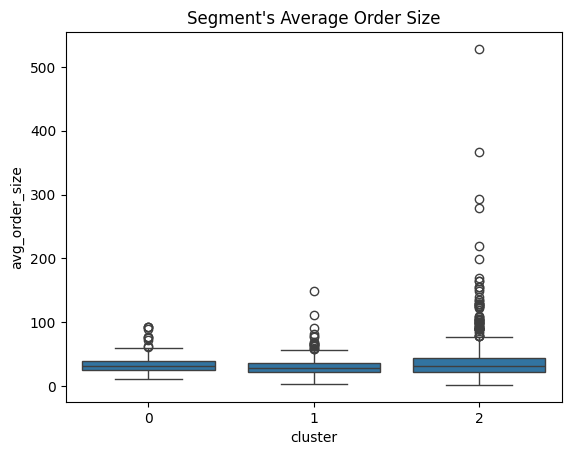

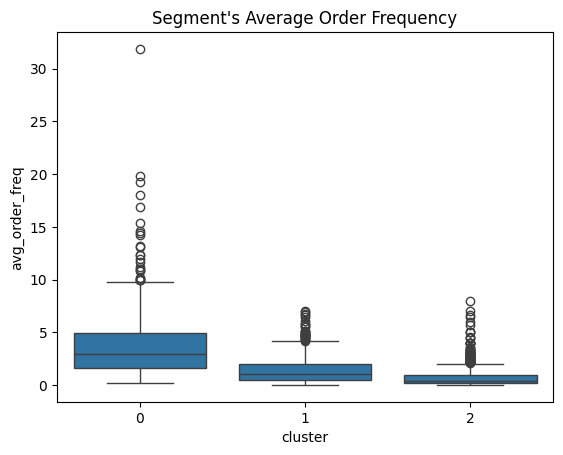

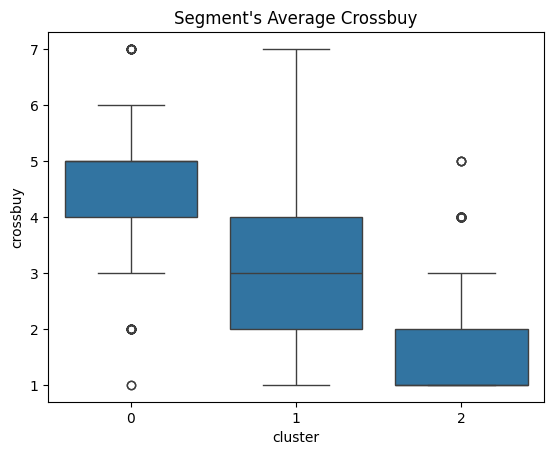

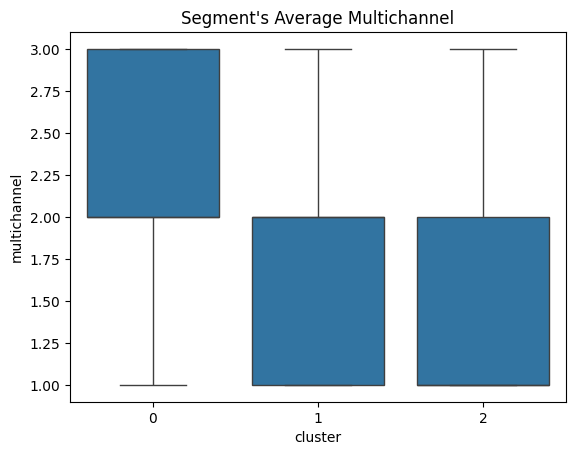

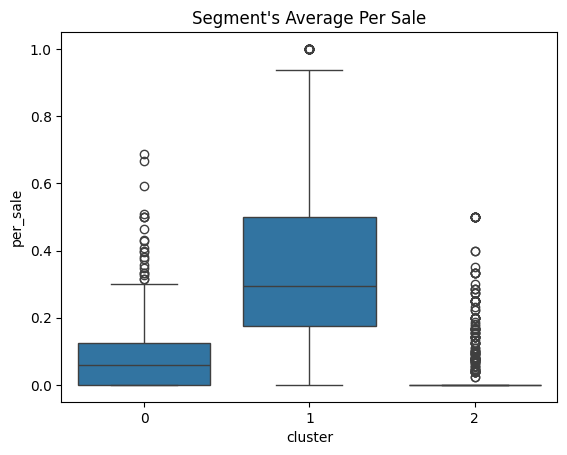

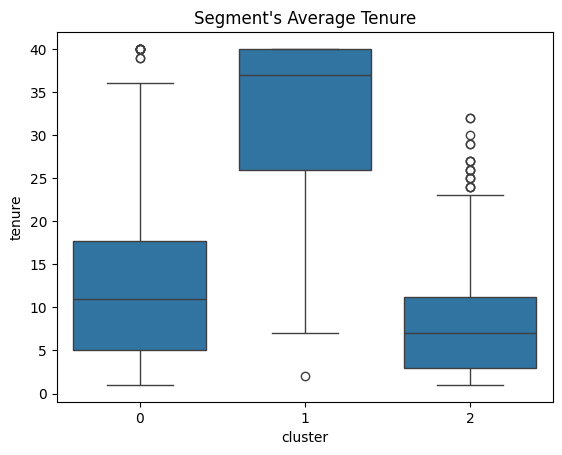

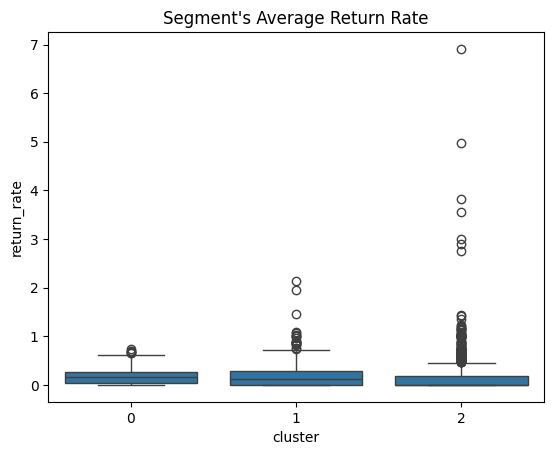

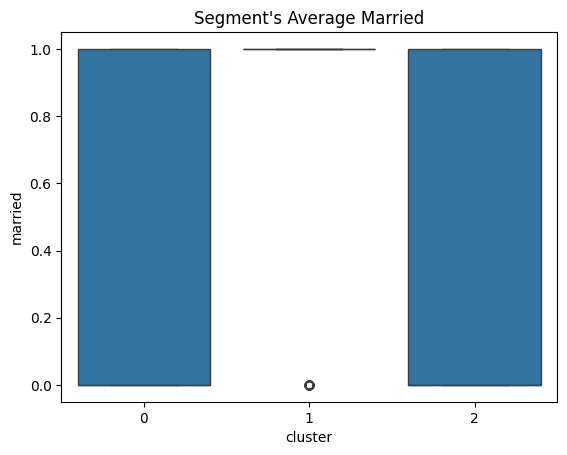

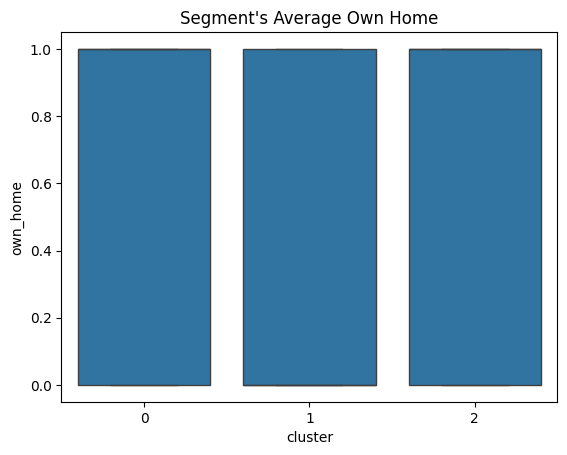

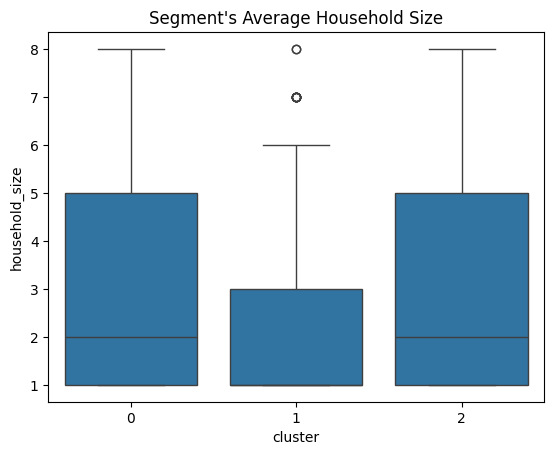

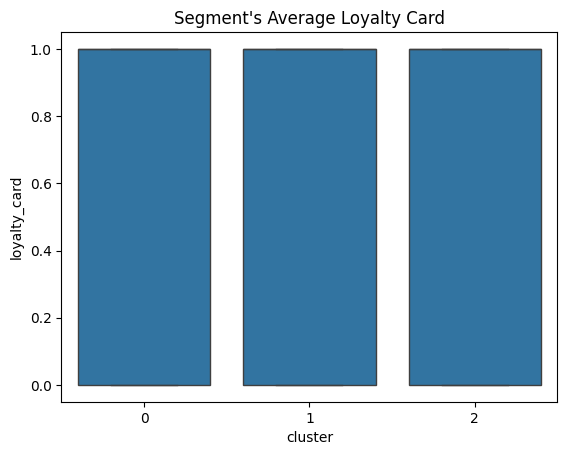

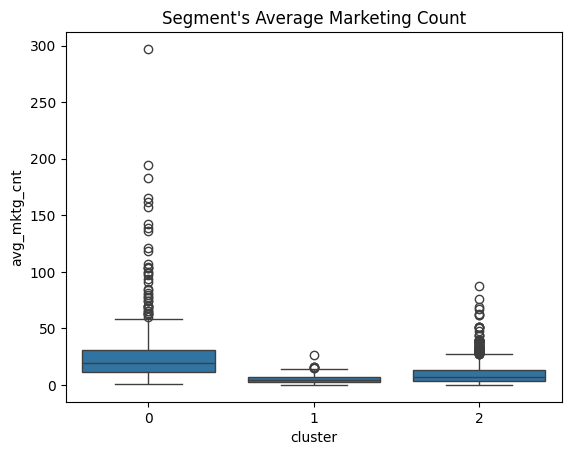

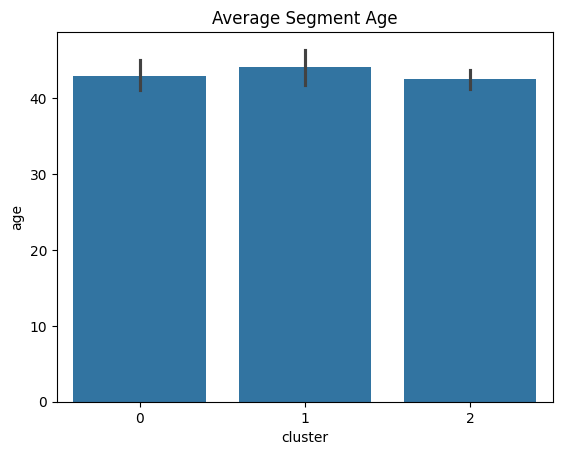

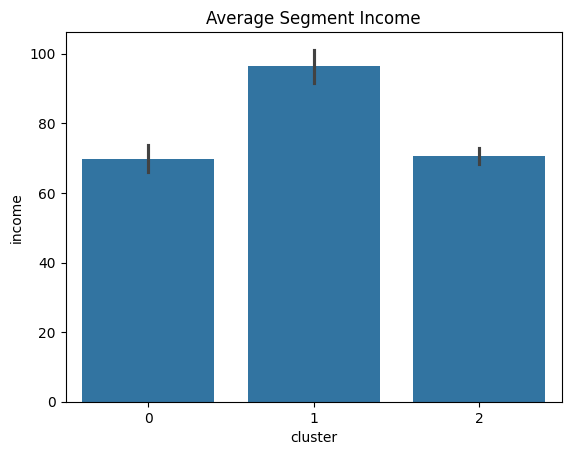

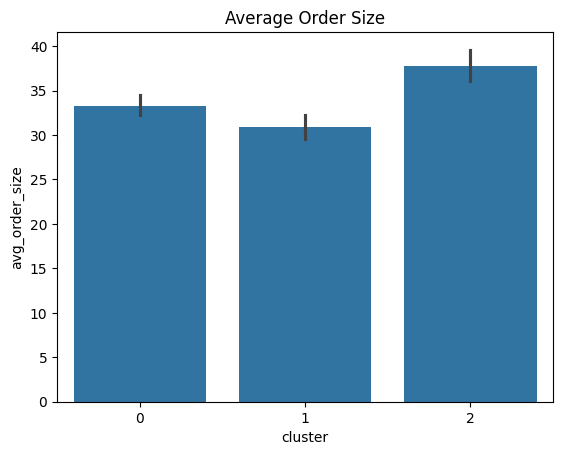

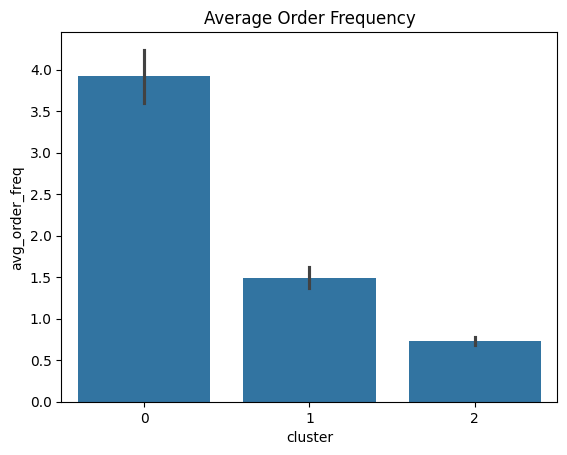

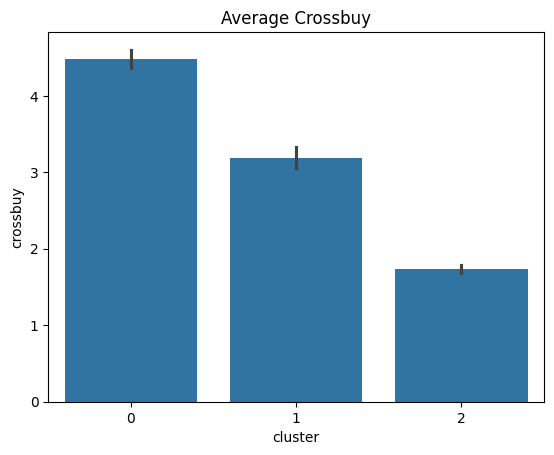

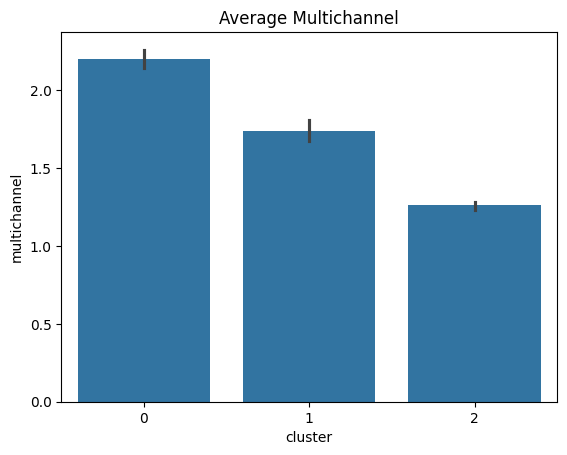

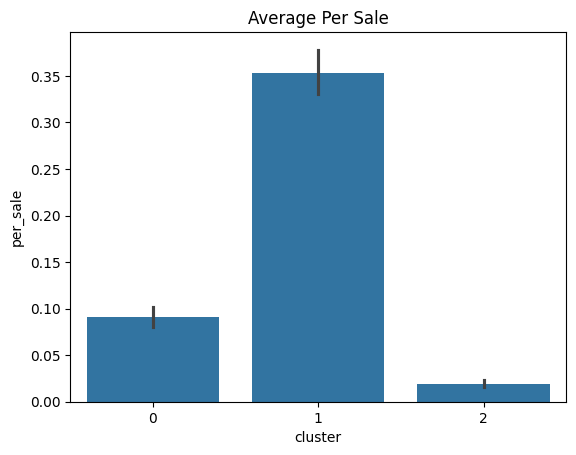

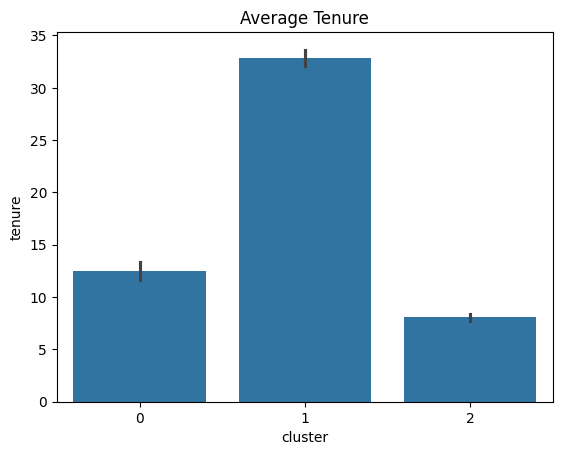

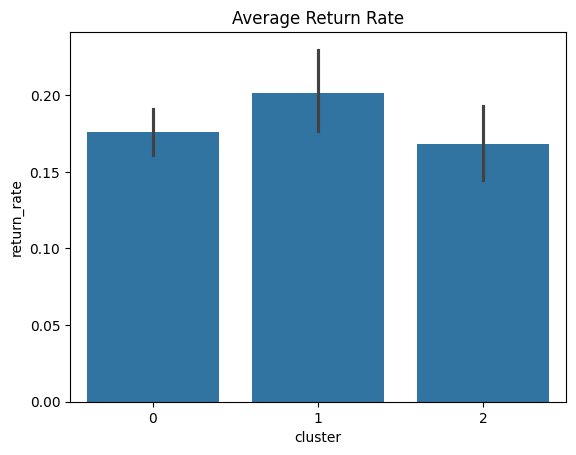

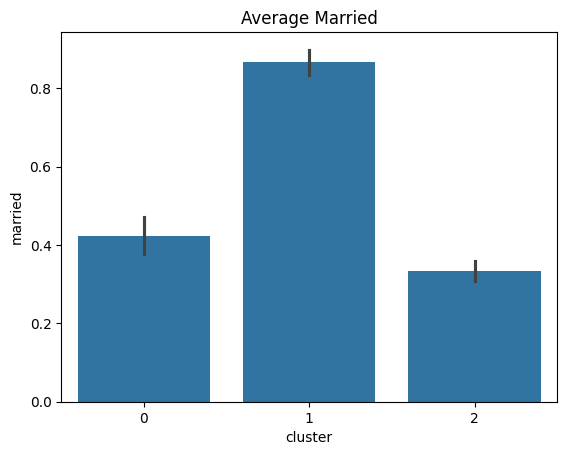

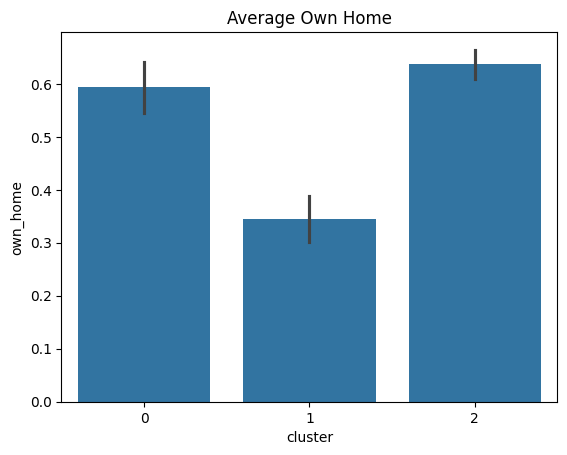

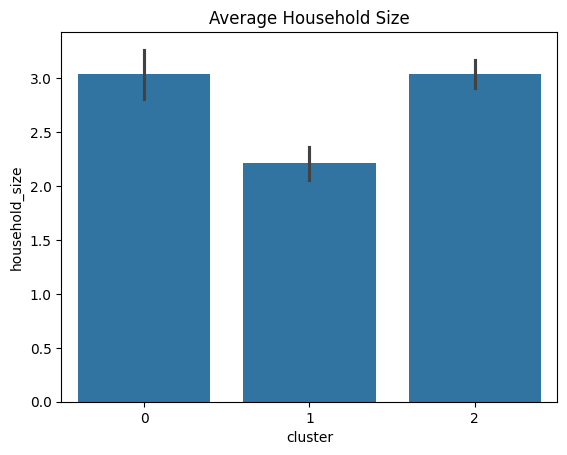

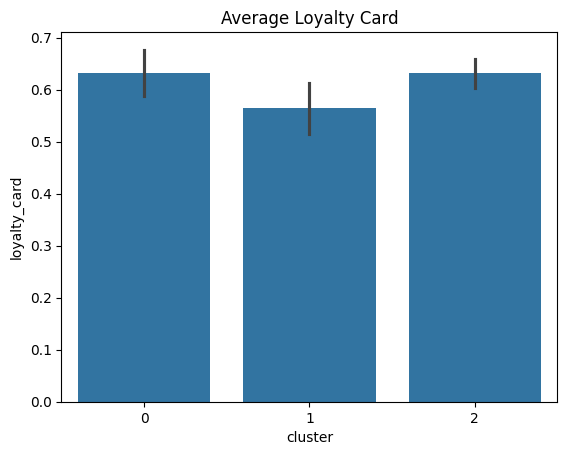

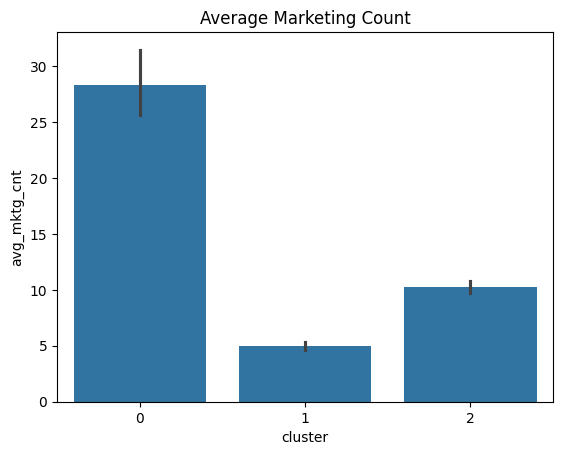

In [ ]:
#Step 2: Two Visualizations of the Data
import seaborn as sns

#Boxplot Features
sns.boxplot(x='cluster', y='age', data=retail_df)
plt.title("Segment's Age")
plt.show()

sns.boxplot(x='cluster', y='income', data=retail_df)
plt.title("Segment's Income")
plt.show()

sns.boxplot(x='cluster', y='avg_order_size', data=retail_df)
plt.title("Segment's Average Order Size")
plt.show()

sns.boxplot(x='cluster', y='avg_order_freq', data=retail_df)
plt.title("Segment's Average Order Frequency")
plt.show()

sns.boxplot(x='cluster', y='crossbuy', data=retail_df)
plt.title("Segment's Average Crossbuy")
plt.show()

sns.boxplot(x='cluster', y='multichannel', data=retail_df)
plt.title("Segment's Average Multichannel")
plt.show()

sns.boxplot(x='cluster', y='per_sale', data=retail_df)
plt.title("Segment's Average Per Sale")
plt.show()

sns.boxplot(x='cluster', y='tenure', data=retail_df)
plt.title("Segment's Average Tenure")
plt.show()

sns.boxplot(x='cluster', y='return_rate', data=retail_df)
plt.title("Segment's Average Return Rate")
plt.show()

sns.boxplot(x='cluster', y='married', data=retail_df)
plt.title("Segment's Average Married")
plt.show()

sns.boxplot(x='cluster', y='own_home', data=retail_df)
plt.title("Segment's Average Own Home")
plt.show()

sns.boxplot(x='cluster', y='household_size', data=retail_df)
plt.title("Segment's Average Household Size")
plt.show()

sns.boxplot(x='cluster', y='loyalty_card', data=retail_df)
plt.title("Segment's Average Loyalty Card")
plt.show()

sns.boxplot(x='cluster', y='avg_mktg_cnt', data=retail_df)
plt.title("Segment's Average Marketing Count")
plt.show()

# Bargraph Features
sns.barplot(x='cluster', y='age', data=retail_df)
plt.title("Average Segment Age")
plt.show()

sns.barplot(x='cluster', y='income', data=retail_df)
plt.title("Average Segment Income")
plt.show()

sns.barplot(x='cluster', y='avg_order_size', data=retail_df)
plt.title("Average Order Size")
plt.show()

sns.barplot(x='cluster', y='avg_order_freq', data=retail_df)
plt.title("Average Order Frequency")
plt.show()

sns.barplot(x='cluster', y='crossbuy', data=retail_df)
plt.title("Average Crossbuy")
plt.show()

sns.barplot(x='cluster', y='multichannel', data=retail_df)
plt.title("Average Multichannel")
plt.show()

sns.barplot(x='cluster', y='per_sale', data=retail_df)
plt.title("Average Per Sale")
plt.show()

sns.barplot(x='cluster', y='tenure', data=retail_df)
plt.title("Average Tenure")
plt.show()

sns.barplot(x='cluster', y='return_rate', data=retail_df)
plt.title("Average Return Rate")
plt.show()

sns.barplot(x='cluster', y='married', data=retail_df)
plt.title("Average Married")
plt.show()

sns.barplot(x='cluster', y='own_home', data=retail_df)
plt.title("Average Own Home")
plt.show()

sns.barplot(x='cluster', y='household_size', data=retail_df)
plt.title("Average Household Size")
plt.show()

sns.barplot(x='cluster', y='loyalty_card', data=retail_df)
plt.title("Average Loyalty Card")
plt.show()

sns.barplot(x='cluster', y='avg_mktg_cnt', data=retail_df)
plt.title("Average Marketing Count")
plt.show()

In [ ]:
#Segment Prediction. Step 1: Preparation
from sklearn.model_selection import train_test_split

#Choose features and target variable
features = ['age', 'income', 'avg_order_size', 'avg_order_freq', 'crossbuy', 'multichannel', 'per_sale', 'tenure', 'return_rate', 'married', 'own_home', 'household_size', 'loyalty_card', 'avg_mktg_cnt']
X = retail_df[features]
y = retail_df['cluster']  #Target variable is customer's segment

#Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

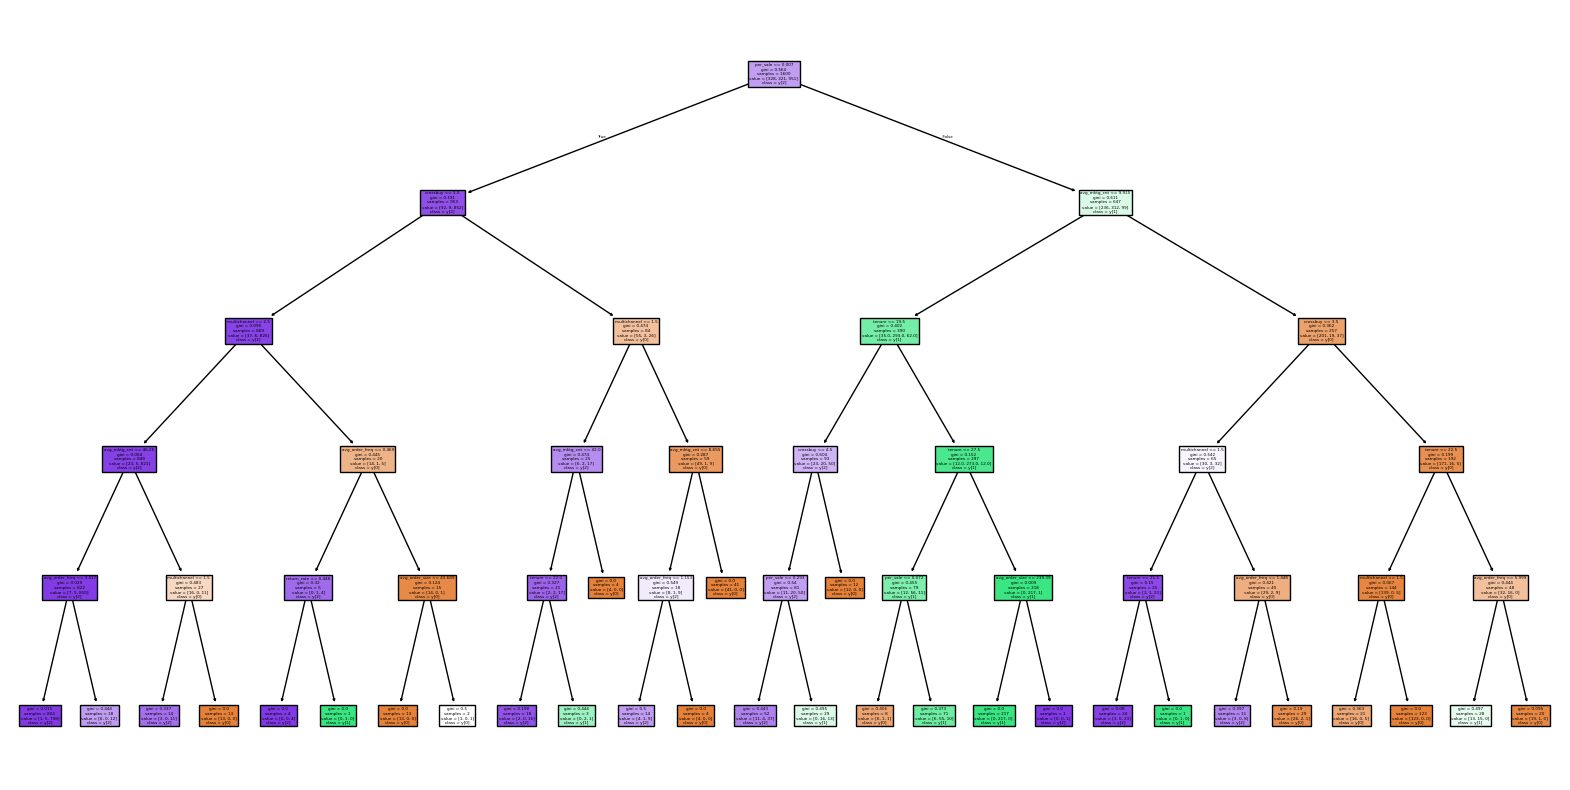

In [ ]:
#Step 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

#Visualise the Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=True, filled=True)
plt.show()

In [ ]:
#Accuracy, Confusion Matrix
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8725
Confusion Matrix:
 [[ 64   6  20]
 [  5  83   5]
 [  9   6 202]]


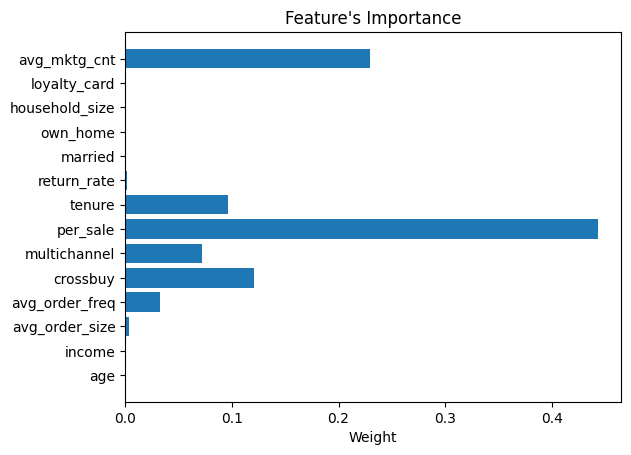

In [ ]:
#Step 4: Features Importance
importances = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importances)
plt.title("Feature's Importance")
plt.xlabel("Weight")
plt.show()